In [1]:
# ! pip install lightkurve

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from piwavelet.plotting.wavelet import (
    plot_wavelet
)

from piwavelet.transforms.cwt import cwt

from piwavelet.diagnostics import compute_wavelet_diagnostics

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
import lightkurve as lk

from lightkurve import search_targetpixelfile

from piwavelet.features.scalogram import (
    wavelet_scalogram,
)

from piwavelet.features.image import (
    resize_scalogram,
    to_uint8,
)

/home/eduardo/Projects/PIWavelet/.venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
def process_lightcurve(
    target,
    mission='Kepler',
    cadence='long',
    period_grid=(0.5, 10),
    n_periods=10000,
    n_bins=256,
    preliminary_window_days=2.0,
    refine_window_factor=10,
    bin_phase=(-0.5, 0.5),
    sector=None,
    verbose=False
):

    if verbose:
        print(f"Processing {target} from {mission}...")

    # -----------------------------------------------------
    # DOWNLOAD
    # -----------------------------------------------------

    if mission == 'TESS' and sector is None:
        raise ValueError("Sector must be specified for TESS targets.")

    if mission == 'Kepler' and sector is not None:
        raise ValueError("Sector should not be specified for Kepler targets.")

    if mission == 'TESS':

        tpf = search_targetpixelfile(target, sector=sector).download()

        lc = (
            tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)
            .remove_nans()
            .remove_outliers()
        )

    else:
        tpf = search_targetpixelfile(
            target,
            author=mission,
            cadence=cadence
        ).download()
        lc = (
            tpf.to_lightcurve(
                aperture_mask=tpf.pipeline_mask
            )
            .remove_nans()
            .remove_outliers()
        )

    # -----------------------------------------------------
    # CADENCE
    # -----------------------------------------------------

    cadence_days = np.median(
        np.diff(lc.time.value)
    )

    # -----------------------------------------------------
    # PRELIMINARY FLATTEN
    # -----------------------------------------------------

    preliminary_window_length = int(
        preliminary_window_days / cadence_days
    )

    if preliminary_window_length % 2 == 0:
        preliminary_window_length += 1

    lc_flat_pre = lc.flatten(
        window_length=preliminary_window_length
    )

    # -----------------------------------------------------
    # BLS
    # -----------------------------------------------------

    periods = np.linspace(
        period_grid[0],
        period_grid[1],
        n_periods
    )

    pg = lc_flat_pre.to_periodogram(
        method='bls',
        period=periods
    )

    period = pg.period_at_max_power
    duration = pg.duration_at_max_power
    transit_time = pg.transit_time_at_max_power

    print(f"Detected period: {period.value:.4f} days")
    print(f"Detected duration: {duration.value:.4f} days")
    print(f"Detected transit time: {transit_time} days")

    # -----------------------------------------------------
    # REFINED FLATTEN
    # -----------------------------------------------------

    refined_window_days = (
        refine_window_factor
        * duration.value
    )

    refined_window_length = int(
        refined_window_days / cadence_days
    )

    if refined_window_length % 2 == 0:
        refined_window_length += 1

    lc_flat = lc.flatten(
        window_length=refined_window_length
    )

    # -----------------------------------------------------
    # FOLD
    # -----------------------------------------------------

    folded = lc_flat.fold(
        period=period,
        epoch_time=transit_time
    )

    # -----------------------------------------------------
    # FIXED ML GRID
    # -----------------------------------------------------

    phase = folded.time.value
    flux = folded.flux.value

    phase_grid = np.linspace(
        bin_phase[0],
        bin_phase[1],
        n_bins
    )

    flux_grid = np.interp(
        phase_grid,
        phase,
        flux
    )

    

    # -----------------------------------------------------
    # NORMALIZATION
    # -----------------------------------------------------

    flux_grid = flux_grid / np.median(flux_grid)

    flux_grid = (flux_grid - flux_grid.min()) / \
        (flux_grid.max() - flux_grid.min())
    
    signal = flux_grid



    normalized_signal = (
        signal - signal.mean()
    ) / signal.std()

    dt = cadence_days
    time = phase_grid

    return signal, normalized_signal, time, dt

In [4]:
# signal, normalized_signal, time, dt= process_lightcurve(
#     "TIC 307210830 c", mission='TESS', sector=2)

signal, normalized_signal, time, dt = process_lightcurve("KIC 10848459")

/home/eduardo/Projects/PIWavelet/.venv/lib/python3.12/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 14 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


Detected period: 1.7370 days
Detected duration: 0.0500 days
Detected transit time: 132.10244084638893 days


In [5]:
scalogram = wavelet_scalogram(
    normalized_signal,
    dt=dt,
    output="power",
    log_transform=True,
    normalization="minmax",
)

print(
    "scalogram shape:",
    scalogram.shape,
)

scalogram shape: (85, 256)


cnn image shape: (224, 224)
uint8


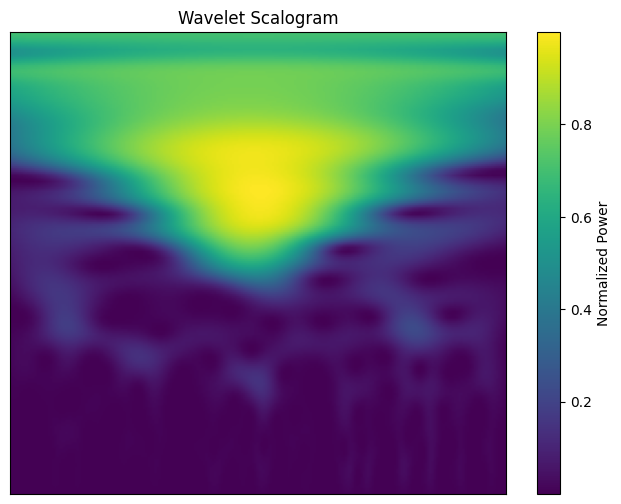

In [6]:

# ----------------------------------------------------------------------
# resize for CNN input
# ----------------------------------------------------------------------

image = resize_scalogram(
    scalogram,
    size=(224, 224),
)

print(
    "cnn image shape:",
    image.shape,
)

# ----------------------------------------------------------------------
# convert to uint8 image
# ----------------------------------------------------------------------

image_uint8 = to_uint8(
    image
)

print(
    image_uint8.dtype
)

# ----------------------------------------------------------------------
# visualize
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6)
)

im = ax.imshow(
    image,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)



ax.set_title(
    "Wavelet Scalogram"
)



fig.colorbar(
    im,
    ax=ax,
    label="Normalized Power",
)
plt.xticks([])
plt.yticks([])

plt.show()

In [7]:
# ----------------------------------------------------------------------
# compute cwt
# ----------------------------------------------------------------------

result = cwt(
    signal=normalized_signal,
    dt=dt,
    time=time,
)

In [8]:
diagnostics = compute_wavelet_diagnostics(
    result,
    signal=signal,
    normalized_signal=normalized_signal,
)

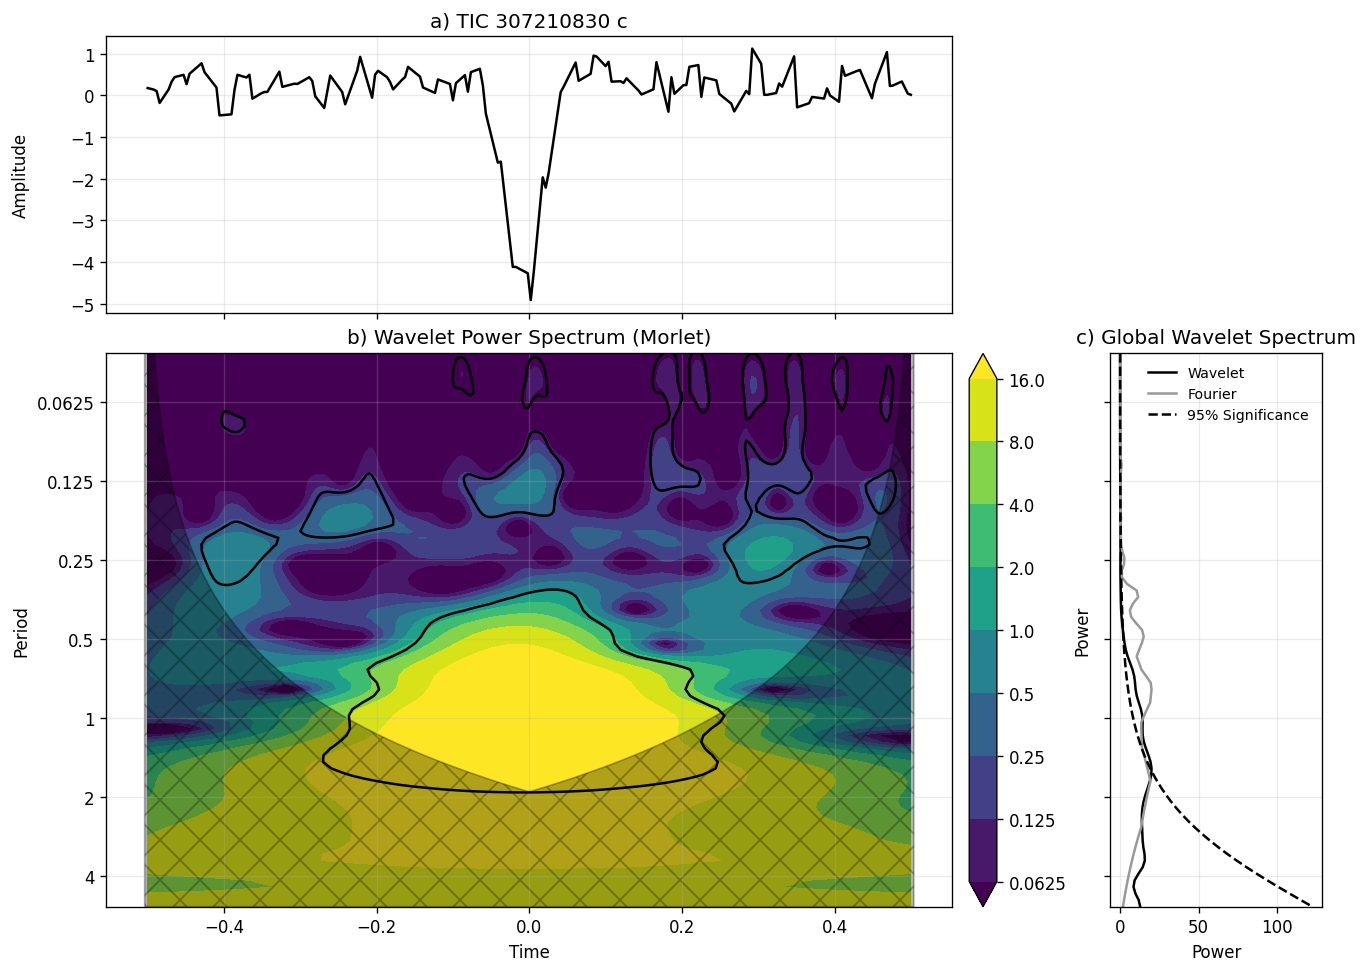

In [9]:
# ----------------------------------------------------------------------
# plot
# ----------------------------------------------------------------------

fig = plot_wavelet(
    diagnostics,
    title="TIC 307210830 c",
    signal_label="Amplitude",
    show_scale_average=False,
)

plt.show()